NAME: SAKSHI JADHAV

ROLL NO.: 23107043

BATCH: C

CLASS: TY-AIDS-A

<h4>Implementing Self-Organizing Maps (SOM) for Image Compression-

1. Implement Kohonen's Self-Organizing Map (SOM) for image compression.
2. Train the SOM to reduce the number of colors in an image.
3. Display the original and compressed images to analyze quality loss.</h4>

In [4]:
!pip install minisom

In [5]:
!pip install Pillow

In [16]:
!pip install scikit-image

In [15]:
from minisom import MiniSom
from PIL import Image  #OR from skimage import io
import numpy as np
import matplotlib.pyplot as plt

<h5>Step 1. Load the image</h5>

In [26]:
img_path = r"C:\Users\Sakshi Jadhav\Downloads\cat.jpg"  # Replace with your image path
 #OR img = io.imread("C:/Users/Sakshi Jadhav/Downloads/cat.jpg")
img = Image.open(img_path)
img = img.convert('RGB')
img = np.array(img) / 255.0
pixels = img.reshape(-1, 3)

<h5>Step 2. Create and train SOM</h5>

In [22]:
lr = 0.5
som_grid_size = 10
som = MiniSom(som_grid_size, som_grid_size, 3, learning_rate=lr)
som.random_weights_init(pixels)
som.train_random(pixels, 100)

<h5>Step 3. Compress the image (manual Euclidean distance)</h5>

In [23]:
weights = som.get_weights().reshape(-1, 3)
compressed_pixels = []
for p in pixels:
    distances = ((weights - p) ** 2).sum(axis=1)
    idx = np.argmin(distances)
    compressed_pixels.append(weights[idx])

compressed_pixels = np.array(compressed_pixels)
compressed_image = compressed_pixels.reshape(img.shape)

<h5>Step 4. Display original and compressed images</h5>

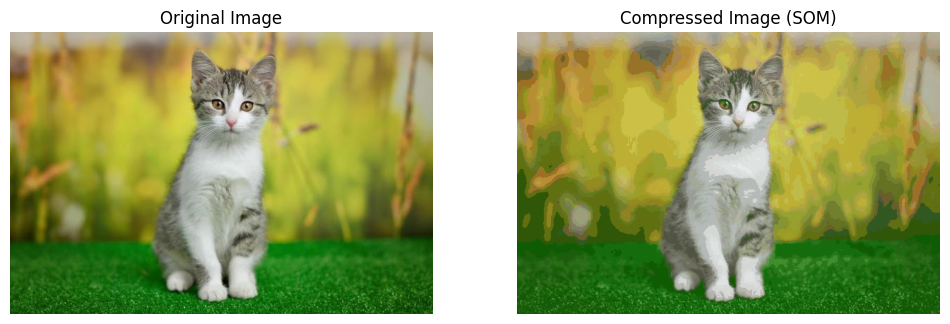

In [24]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Compressed Image (SOM)")
plt.imshow(compressed_image)
plt.axis('off')

plt.show()